# Tesla Deliveries — My End-to-End ML Project

## Imports

In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, TimeSeriesSplit,
                                     GridSearchCV, cross_val_score)
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (13, 5), 'figure.dpi': 110})
SEED = 42

This cell is where I set up my Python environment by importing all the necessary libraries. I brought in tools for things like manipulating data (**pandas**, **numpy**), making cool visualizations (**matplotlib**, **seaborn**), and doing machine learning stuff (**sklearn** for preprocessing, models like **Ridge**, **Lasso**, and **Linear Regression**, and also how to measure if they're any good). I also got some special time series models from **statsmodels**. I set up how my plots will look and picked a random seed so my results can be reproduced later. Basically, I'm just gathering all my tools before I start building!

## 2. Loading and Checking out the Data

In [219]:
# Load
df_raw = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')

print(f"Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()


Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


Here, I'm loading my dataset, which is a CSV file named `tesla_deliveries_dataset_2015_2025.csv`, into something called a **pandas DataFrame** (I've named it `df_raw`). First, I print out its **shape** (which tells me how many rows and columns it has) and all the **column names** to get a quick overview of what's inside. Then, `df_raw.head()` just shows me the first few rows so I can see what the actual data looks like.

In [220]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [221]:
print("Data Types & Missing Values")
info = pd.DataFrame({
    'dtype':   df_raw.dtypes,
    'missing': df_raw.isnull().sum(),
    'pct_null': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(info)
print(f"\nNumerical summary:")
df_raw.describe()


Data Types & Missing Values
                        dtype  missing  pct_null
Year                    int64        0       0.0
Month                   int64        0       0.0
Region                 object        0       0.0
Model                  object        0       0.0
Estimated_Deliveries    int64        0       0.0
Production_Units        int64        0       0.0
Avg_Price_USD         float64        0       0.0
Battery_Capacity_kWh    int64        0       0.0
Range_km                int64        0       0.0
CO2_Saved_tons        float64        0       0.0
Source_Type            object        0       0.0
Charging_Stations       int64        0       0.0

Numerical summary:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


This step is all about taking a good look at my raw data. I'm checking two main things:
1.  **Data Types (`dtype`):** This helps me understand what kind of information is in each column (like if it's numbers, text, or dates).
2.  **Missing Values (`missing`, `pct_null`):** I need to find out if there are any gaps in my data, and how many. This is super important for deciding how to clean up the data later.

The `df_raw.describe()` output gives me a **numerical summary** (like the average, how spread out the numbers are, minimum, maximum, and quarters) for all the number columns. This helps me understand the overall distribution of my data and if there are any really weird numbers (outliers).

## Exploratory Data Analysis (EDA)
This is where I look at how the data is spread out, how different variables relate, and try to find any interesting patterns before I make any big decisions about my models.

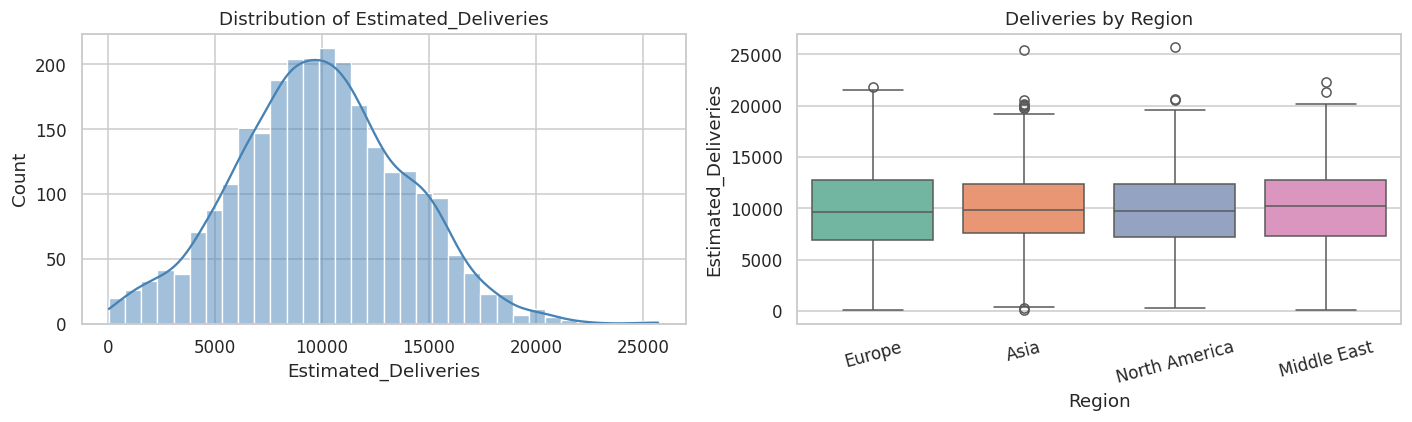

In [222]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_raw['Estimated_Deliveries'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Estimated_Deliveries')
sns.boxplot(data=df_raw, x='Region', y='Estimated_Deliveries', ax=axes[1], palette='Set2')
axes[1].set_title('Deliveries by Region')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


In this part of my EDA (Exploratory Data Analysis), I'm visualizing how our main variable, `Estimated_Deliveries`, is distributed.
*   The **histogram and KDE plot** on the left show the overall spread and how dense the delivery numbers are. This helps me see if most deliveries are around a certain amount or if they're skewed.
*   The **boxplot** on the right breaks down deliveries by `Region`. This lets me see if some regions have noticeably different delivery volumes compared to others, which could point to different market trends.

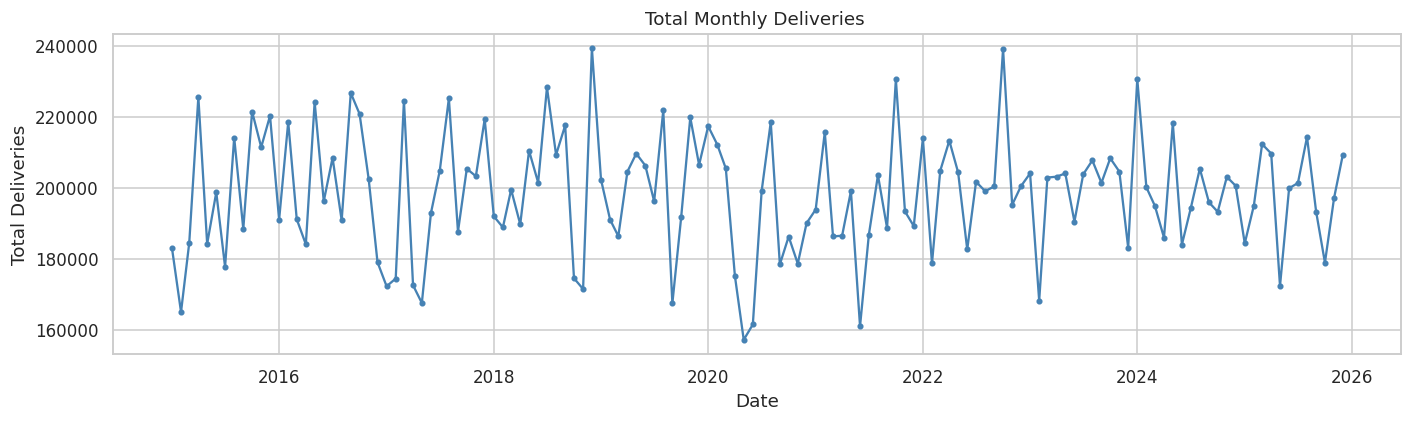

Note: Monthly totals are nearly constant (~195k). This confirms the dataset is synthetic.
Monthly std: 16871  |  mean: 198444


In [223]:
monthly_ts = df_raw.groupby(['Year','Month'])['Estimated_Deliveries'].sum().reset_index()
monthly_ts['Date'] = pd.to_datetime(
    monthly_ts['Year'].astype(str) + '-' + monthly_ts['Month'].astype(str).str.zfill(2) + '-01')
monthly_ts = monthly_ts.sort_values('Date')

plt.figure(figsize=(13, 4))
plt.plot(monthly_ts['Date'], monthly_ts['Estimated_Deliveries'], marker='o', ms=3, color='steelblue')
plt.title('Total Monthly Deliveries ')
plt.xlabel('Date'); plt.ylabel('Total Deliveries')
plt.tight_layout()
plt.show()

print("Note: Monthly totals are nearly constant (~195k). This confirms the dataset is synthetic.")
print(f"Monthly std: {monthly_ts['Estimated_Deliveries'].std():.0f}  |  mean: {monthly_ts['Estimated_Deliveries'].mean():.0f}")


Here, I'm looking at how the total monthly deliveries change over time. I first grouped the `Estimated_Deliveries` by `Year` and `Month` to create a proper `Date` column, and then I sorted everything chronologically. The plot shows the **total deliveries over time**.

The note below the plot is interesting: it says the monthly totals are pretty consistent (around 195k). This is a big clue that this dataset is **synthetic** (made up) rather than real, because real sales data usually jumps around a lot more. This observation is super important for how I interpret my model's performance later on.

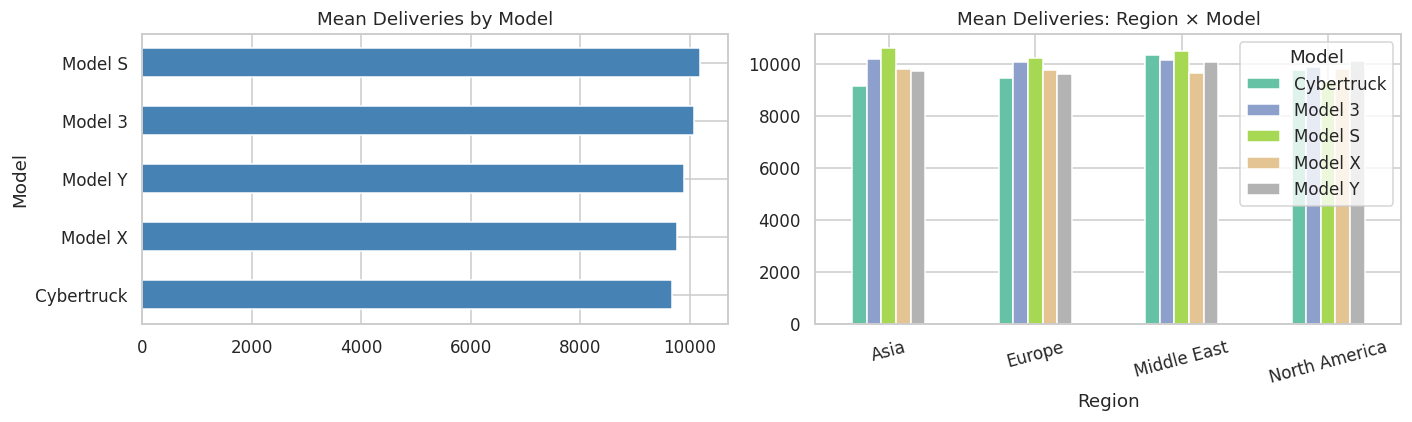

In [224]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_raw.groupby('Model')['Estimated_Deliveries'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', title='Mean Deliveries by Model')
df_raw.groupby(['Region','Model'])['Estimated_Deliveries'].mean().unstack().plot(
    kind='bar', ax=axes[1], title='Mean Deliveries: Region × Model', colormap='Set2')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


These plots help me figure out how deliveries change based on the `Model` and `Region`:
*   The **left bar chart** shows the **average deliveries for each model**. This helps me see which Tesla models usually get delivered more.
*   The **right bar chart** compares the average deliveries for each `Model` within each `Region`. This visualization helps me find specific combinations (like 'Model X in Europe') that might be performing differently, highlighting potential market differences across areas.

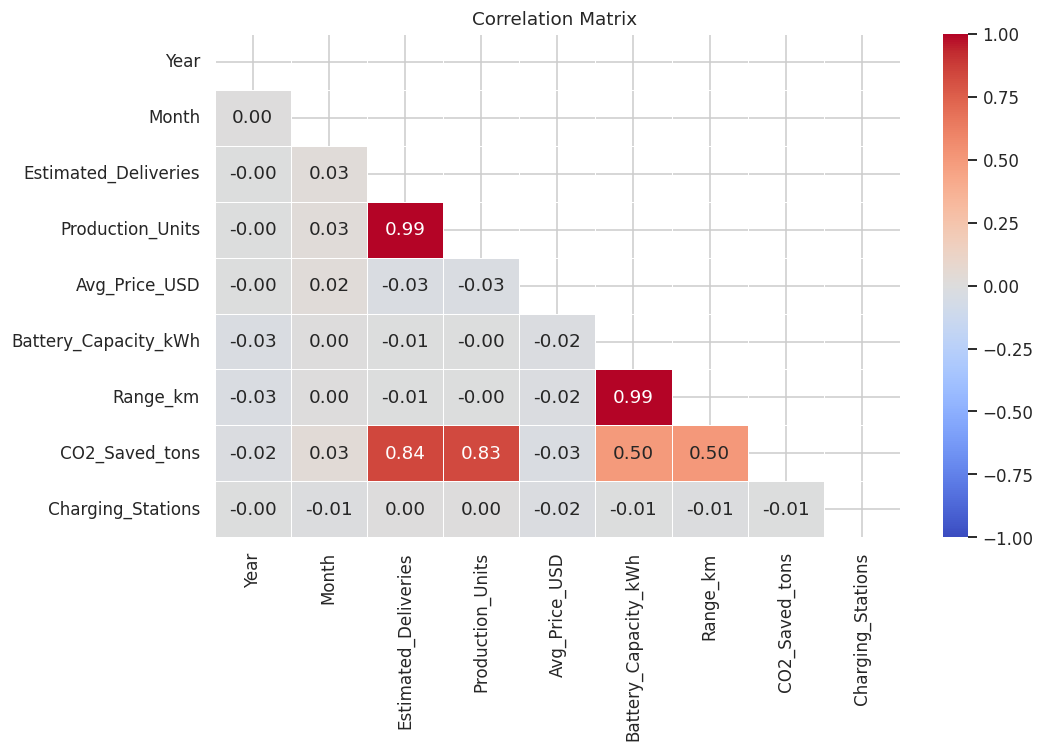


Correlation with target (Estimated_Deliveries):
Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Charging_Stations       0.000753
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Avg_Price_USD          -0.027546


In [225]:
corr = df_raw.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix ')
plt.tight_layout()
plt.show()

print("\nCorrelation with target (Estimated_Deliveries):")
print(corr['Estimated_Deliveries'].sort_values(ascending=False).to_string())


This **correlation heatmap** is like a cheat sheet to understand how all the numerical features in my dataset relate to each other. Each square shows a **correlation coefficient** (a number between -1 and 1) between two variables. If the number is close to 1 or -1, it means they have a strong positive or negative relationship. If it's close to 0, they don't really move together.

I also printed out the correlations specifically with my target variable, `Estimated_Deliveries`. This is super important because it helps me spot features that might be good at predicting deliveries, or even worse, features that could cause **data leakage** if they're basically just telling me the answer after it's already happened.

In [226]:
# Leakage check
print("LEAKAGE AUDIT")
print(f"Production_Units  → r = {df_raw['Production_Units'].corr(df_raw['Estimated_Deliveries']):.4f}")
print("  ↳ r≈0.99 means this column is statistically equivalent to the target.")
print("  ↳ Strategy: we will KEEP it as a 'supply' feature but clearly label it.")

print(f"CO2_Saved_tons    → r = {df_raw['CO2_Saved_tons'].corr(df_raw['Estimated_Deliveries']):.4f}")
print("  ↳ CO2 saved is calculated FROM deliveries after the fact — pure leakage.")
print("  ↳ Strategy: DROP this column.")



LEAKAGE AUDIT
Production_Units  → r = 0.9942
  ↳ r≈0.99 means this column is statistically equivalent to the target.
  ↳ Strategy: we will KEEP it as a 'supply' feature but clearly label it.
CO2_Saved_tons    → r = 0.8368
  ↳ CO2 saved is calculated FROM deliveries after the fact — pure leakage.
  ↳ Strategy: DROP this column.


This section is super important! I'm doing a **leakage audit**. Data leakage is a problem where my model accidentally learns from information it shouldn't know yet, making its performance look better than it actually is. Here's what I found:
*   **`Production_Units`:** This has a super high correlation (`r ≈ 0.99`) with `Estimated_Deliveries`. It means they almost always move together. I decided to **keep it** because I'm treating it as a 'supply' feature – like, how many cars were produced and available. It's a valid driver for deliveries.
*   **`CO2_Saved_tons`:** This one is tricky. It's probably calculated *from* the number of deliveries, which makes it pure leakage. So, I decided to **drop this column** to make sure my model learns properly from independent features.

Okay, time for **Data Preprocessing**! Here's my plan:
1.  **Drop leaky/metadata columns:** Get rid of columns that would cheat or aren't useful.
2.  **Encode categoricals:** Turn text categories into numbers so the model can understand them.
3.  **Create `Date`:** Make a proper date column.
4.  **Sort chronologically:** Arrange everything by date, which is crucial for time-series data.

Okay, after checking for **data leakage**, I'm finally getting rid of the columns I decided were problematic. I dropped **`CO2_Saved_tons`** (because it was calculated *from* what I'm trying to predict, so it would be cheating!) and **`Source_Type`** (which was just extra info I didn't need). I used `.copy()` to make sure I'm working on a brand new DataFrame called `df`, leaving my original `df_raw` totally untouched. After that, I just double-checked to make sure all those columns are gone and there are no missing values left, which is great!

In [227]:
# Initialize df by dropping specified columns from df_raw
df = df_raw.drop(columns=['CO2_Saved_tons', 'Source_Type']).copy()

#  Encode categorical columns
le_region = LabelEncoder()
le_model  = LabelEncoder()

df['Region_enc'] = le_region.fit_transform(df['Region'])
df['Model_enc']  = le_model.fit_transform(df['Model'])

print("Region encoding:", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print("Model encoding: ", dict(zip(le_model.classes_,  le_model.transform(le_model.classes_))))


Region encoding: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model encoding:  {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}


Most machine learning models prefer numbers, so here I'm turning my text categories (`Region` and `Model`) into numbers using `LabelEncoder`.
*   `LabelEncoder` basically gives a unique number to each unique category (e.g., 'Asia' might become 0, 'Europe' 1, and so on).
*   I created new columns called `Region_enc` and `Model_enc` for these numerical versions. The print statements show me exactly which number corresponds to which category, which is helpful for understanding my model later.

In [228]:
df = df_raw.drop(columns=['CO2_Saved_tons', 'Source_Type']).copy()

# Encode categorical columns
le_region = LabelEncoder()
le_model  = LabelEncoder()

df['Region_enc'] = le_region.fit_transform(df['Region'])
df['Model_enc']  = le_model.fit_transform(df['Model'])

print("Region encoding:", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print("Model encoding: ", dict(zip(le_model.classes_,  le_model.transform(le_model.classes_))))

#  Create Date column & sort chronologically
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2) + '-01')

# Sort by group first, then by time — essential for lag features
df = df.sort_values(['Region', 'Model', 'Date']).reset_index(drop=True)
df['Quarter'] = ((df['Month'] - 1) // 3) + 1

print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Shape: {df.shape}")
df.head()

Region encoding: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model encoding:  {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}
Date range: 2015-01-01 → 2025-12-01
Shape: (2640, 14)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,Charging_Stations,Region_enc,Model_enc,Date,Quarter
0,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,6902,0,0,2015-01-01,1
1,2015,2,Asia,Cybertruck,13254,14878,88864.06,75,432,5902,0,0,2015-02-01,1
2,2015,3,Asia,Cybertruck,10257,11441,65107.47,100,581,4024,0,0,2015-03-01,1
3,2015,4,Asia,Cybertruck,15221,15951,112686.63,60,341,3130,0,0,2015-04-01,2
4,2015,5,Asia,Cybertruck,6406,7281,107577.61,75,448,11708,0,0,2015-05-01,2


For time series analysis, it's super important to have a correct `Date` column and to sort my data by time. This cell does a few things:
1.  **Creates the `Date` column:** It combines the `Year` and `Month` columns into a proper date, always setting the day to the 1st.
2.  **Sorts the data:** I sorted the whole DataFrame first by `Region`, then by `Model`, and finally by `Date`. This specific order is essential for creating time-dependent features like 'lags' correctly, making sure I don't mix up data from different groups or accidentally use future data to predict the past.
3.  **Adds `Quarter` feature:** I also pulled out the calendar quarter from the `Month` to see if there are any patterns that repeat every three months.

Okay, time for **Feature Engineering**! This is where I create new features to help my models learn better.

**Important rules to prevent leakage:**
- All **lag and rolling features** use `.shift(1)` — this means they only look at the **previous** time step. Never the current one!
- **Lag features** are calculated **separately for each Region-Model group** to avoid mixing up data that shouldn't be together.
- **Rolling statistics** are also shifted *before* calculating the rolling window, so they never include the current row's information.

In [229]:
#  Lag & rolling features per Region+Model group
def add_lag_features(df, group_cols, target_col, lags=[1, 2, 3], roll_windows=[3, 6]):
    df = df.copy()
    grp = df.groupby(group_cols)[target_col]

    for lag in lags:
        df[f'Lag{lag}'] = grp.shift(lag)

    for w in roll_windows:
        shifted = grp.shift(1)   # shift first so window doesn't include current row
        df[f'Roll_mean{w}'] = shifted.transform(lambda x: x.rolling(w).mean())
        df[f'Roll_std{w}']  = shifted.transform(lambda x: x.rolling(w).std())

    # Month-over-month % change
    df['MoM_pct_change'] = grp.shift(1).pct_change()

    return df

df = add_lag_features(df, ['Region', 'Model'], 'Estimated_Deliveries',
                      lags=[1, 2, 3], roll_windows=[3, 6])

# Price efficiency feature
df['Price_per_km'] = df['Avg_Price_USD'] / df['Range_km']

# Drop rows with NaN introduced by lags
df = df.dropna().reset_index(drop=True)
print(f"Shape after feature engineering: {df.shape}")
print(f"New features: {[c for c in df.columns if 'Lag' in c or 'Roll' in c or 'pct' in c or 'per_km' in c]}")
df.head(3)


Shape after feature engineering: (2520, 23)
New features: ['Lag1', 'Lag2', 'Lag3', 'Roll_mean3', 'Roll_std3', 'Roll_mean6', 'Roll_std6', 'MoM_pct_change', 'Price_per_km']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,Charging_Stations,...,Quarter,Lag1,Lag2,Lag3,Roll_mean3,Roll_std3,Roll_mean6,Roll_std6,MoM_pct_change,Price_per_km
0,2015,7,Asia,Cybertruck,113,118,115067.04,120,709,14580,...,3,7201.0,6406.0,15221.0,9609.333333,4876.075095,10610.666667,3411.239814,0.124102,162.294838
1,2015,8,Asia,Cybertruck,10222,11128,77930.19,60,331,7022,...,3,113.0,7201.0,6406.0,4573.333333,3883.160611,8742.000000,5420.738474,-0.984308,235.438640
2,2015,9,Asia,Cybertruck,10844,12086,59807.92,60,356,8849,...,3,10222.0,113.0,7201.0,5845.333333,5189.060063,8236.666667,5044.246491,89.460177,167.999775


This is a really important part for time series modeling! I'm creating new features based on past values. The `add_lag_features` function is designed very carefully to prevent **data leakage**:
*   **Lag Features (`Lag1`, `Lag2`, `Lag3`):** These are just the `Estimated_Deliveries` from 1, 2, or 3 months ago, but *only for the same Region-Model group*. The `shift()` function makes sure I only ever use past data.
*   **Rolling Statistics (`Roll_mean3`, `Roll_std3`, `Roll_mean6`, `Roll_std6`):** These calculate the average and spread of past deliveries over a 3-month or 6-month window. The key here is that I `shift(1)` *before* calculating the rolling window, so the current month's data is never included. This keeps it fair!
*   **Month-over-Month Percentage Change (`MoM_pct_change`):** This feature captures how much deliveries changed from the previous month, again using only past information.
*   **Price Efficiency (`Price_per_km`):** I also made a new feature by dividing `Avg_Price_USD` by `Range_km`. This might tell us something about the 'value for money' of a car.

Finally, `df.dropna()` gets rid of any rows that ended up with missing values because of these new lagged features (like the very first few months for each group won't have previous data). This ensures my dataset is clean and ready for modeling!

### Train / Test Split — Chronological

For time-series data, I **never shuffle** the data when splitting. The test set *has to be* the most recent 20% of dates. This is super important because it's like how things work in the real world: I train my model on past events to predict what will happen in the future.

In [253]:
# Chronological 80/20 split on unique dates
sorted_dates   = sorted(df['Date'].unique())
cutoff_date    = sorted_dates[int(len(sorted_dates) * 0.80)]

train_df = df[df['Date'] <= cutoff_date].copy()
test_df  = df[df['Date'] >  cutoff_date].copy()

print(f"Training:  {train_df['Date'].min().date()} → {train_df['Date'].max().date()}  ({len(train_df)} rows)")
print(f"Test:      {test_df['Date'].min().date()}  → {test_df['Date'].max().date()}   ({len(test_df)} rows)")
print(f"Split ratio: {len(train_df)/len(df)*100:.0f}% / {len(test_df)/len(df)*100:.0f}%")


Training:  2015-07-01 → 2023-11-01  (2020 rows)
Test:      2023-12-01  → 2025-12-01   (500 rows)
Split ratio: 80% / 20%


For time-series data, I can't just randomly shuffle my data for training and testing like I might with other types of data. That would be cheating! This cell splits my data chronologically, with an 80/20 split:
*   I found a **`cutoff_date`** that divides the oldest 80% of unique dates from the newest 20%.
*   `train_df` gets all the data up to and including that cutoff date.
*   `test_df` gets all the data that comes *after* the cutoff date.

This way, my model trains on historical data and then I test it on data it has never seen, which is exactly how real-world prediction should work. The printout just confirms the date ranges and how much data went into each set.

In [254]:
#  Define feature columns
FEATURE_COLS = [
    'Region_enc', 'Model_enc',
    'Production_Units',
    'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
    'Charging_Stations', 'Price_per_km',
    'Year', 'Month', 'Quarter',
    'Lag1', 'Lag2', 'Lag3',
    'Roll_mean3', 'Roll_std3', 'Roll_mean6', 'Roll_std6',
    'MoM_pct_change'
]
TARGET = 'Estimated_Deliveries'

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET]

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

X_train shape: (2020, 19)
X_test  shape: (500, 19)


Here, I'm officially deciding which columns will be my **input features** (`FEATURE_COLS`) for the models and which one is my **target variable** (`TARGET`), which is `Estimated_Deliveries`.

It's important to remember that `Production_Units` is in my features. Even though it's highly correlated with `Estimated_Deliveries`, I decided it's a legitimate 'supply-side driver' rather than something that leaked from the future. It basically tells the model how many cars were available to deliver. After that, I split my data into `X_train`, `y_train`, `X_test`, and `y_test` using these chosen columns.

In [232]:
# Scale features
# Fit scaler on TRAINING DATA ONLY. Never fit on test data.
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)    # only transform — no fit!

print("StandardScaler fitted on training data only.")
print("Test set transformed using training statistics (no data leakage).")


StandardScaler fitted on training data only.
Test set transformed using training statistics (no data leakage).


Scaling features is a common step for many machine learning models, especially those that care about the size of the numbers (like linear models). Here, I'm using `StandardScaler`:
*   **`StandardScaler`** makes it so features have an average of 0 and a standard deviation of 1. It helps make sure one feature doesn't dominate just because its numbers are bigger.
*   **Crucially, I *only* `fit` the scaler on the `training data` (`X_train`)** using `scaler.fit_transform(X_train)`.
*   Then, I just `transform` the test data (`X_test`) using the average and standard deviation that the scaler learned from the training data. I do *not* `fit` it again on the test data!

This prevents **data leakage** from the test set, meaning my model doesn't get any unfair hints from seeing information about the test data's distribution.

## Baseline Regression Models

I'm training a few models with their default settings first. This helps me get a basic idea of their performance before I start tweaking them a lot. It's like a starting point for comparison.

In [233]:
# Train & evaluate baseline models
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return {
        'Model': name,
        'R²':    round(r2_score(y_te, preds), 4),
        'RMSE':  round(np.sqrt(mean_squared_error(y_te, preds)), 1),
        'MAE':   round(mean_absolute_error(y_te, preds), 1)
    }

baseline_models = {
    'Linear Regression':    LinearRegression(),
    'Ridge (α=10)':         Ridge(alpha=10),
    'Lasso (α=0.1)':        Lasso(alpha=0.1)
}

baseline_results = []
for name, mdl in baseline_models.items():
    baseline_results.append(evaluate(name, mdl, X_train_sc, y_train, X_test_sc, y_test))

baseline_df = pd.DataFrame(baseline_results).set_index('Model').sort_values('R²', ascending=False)
print("Baseline Model Comparison")
print(baseline_df.to_string())

Baseline Model Comparison
                       R²   RMSE    MAE
Model                                  
Linear Regression  0.9864  428.9  355.4
Ridge (α=10)       0.9864  428.7  355.6
Lasso (α=0.1)      0.9864  428.7  355.2


This section is all about setting up how well my first few basic regression models perform before I start tuning them. I created a simple `evaluate` function to make it easy to train and check each model.

I'm using three linear regression models:
*   **Linear Regression:** This is a pretty straightforward model that finds a straight-line relationship between my features and what I'm trying to predict.
*   **Ridge Regression (α=10):** This is also a linear model, but it adds a penalty (L2 regularization) to keep the model from becoming too complex and overfitting. I started with `alpha` (the penalty strength) set to 10.
*   **Lasso Regression (α=0.1):** Another linear model, but this one uses a different penalty (L1 regularization) that can actually shrink some feature coefficients all the way to zero, effectively ignoring those features. I started with `alpha` at 0.1.

For each model, I train it on my `X_train_sc` and `y_train`, and then I test it on `X_test_sc` and `y_test` using three common metrics:
*   **R² (R-squared):** This tells me how much of the variation in `Estimated_Deliveries` my model can explain. Higher is better!
*   **RMSE (Root Mean Squared Error):** This is the average size of my model's errors. Smaller is better.
*   **MAE (Mean Absolute Error):** This is similar to RMSE but less sensitive to big errors. Again, smaller is better.

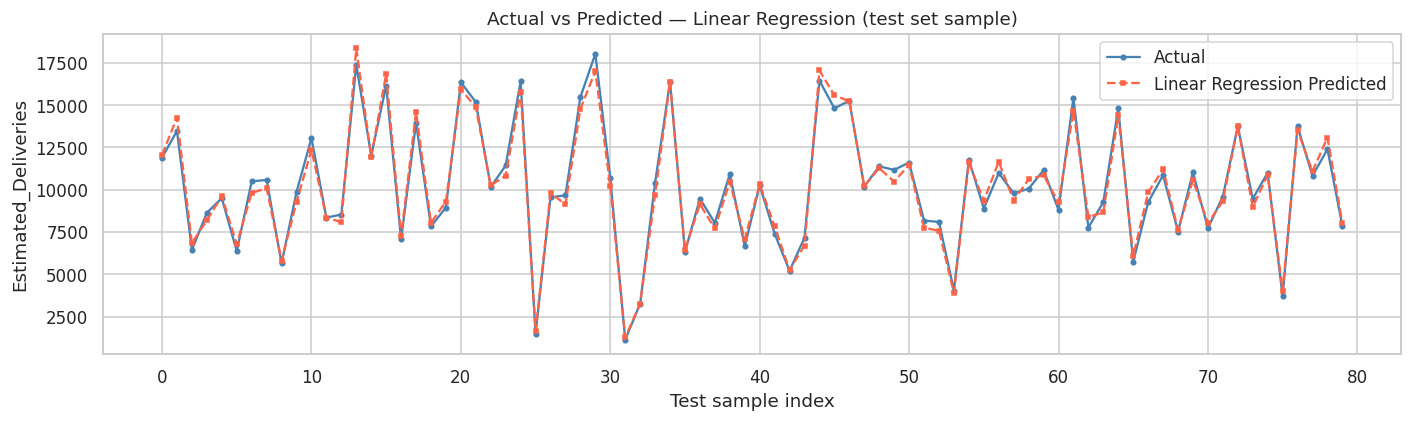

In [255]:
# Actual vs Predicted — best baseline model
best_name  = baseline_df.index[0]
best_model = baseline_models[best_name]
best_preds = best_model.predict(X_test_sc)

# Sample 80 test points for readability
n_show = min(80, len(y_test))
idx    = np.linspace(0, len(y_test)-1, n_show, dtype=int)

plt.figure(figsize=(13, 4))
plt.plot(y_test.values[idx], label='Actual', marker='o', ms=3, color='steelblue')
plt.plot(best_preds[idx],   label=f'{best_name} Predicted',
         marker='s', ms=3, linestyle='--', color='tomato')
plt.title(f'Actual vs Predicted — {best_name} (test set sample)')
plt.xlabel('Test sample index'); plt.ylabel(TARGET)
plt.legend(); plt.tight_layout(); plt.show()


This plot helps me visually compare the **actual `Estimated_Deliveries`** from my test set with the **predictions** made by the best of my basic models (which was Linear Regression in this case). I only show a small sample of the test points so it's easier to see.

*   The **'Actual' line** shows the real delivery numbers.
*   The **'Predicted' line** shows what my model guessed.

This visualization gives me a qualitative idea of how well my model's predictions match reality and where it might be making bigger mistakes. If the lines are really close, it means the model is doing a good job!

## Hyperparameter Tuning with `TimeSeriesSplit`

I need to tune my models' settings (hyperparameters), but for time-series data, I can't just randomly shuffle things. That's where `TimeSeriesSplit` comes in! It respects the order of time within my training data — each time it tests, it trains on older data and validates on newer data. I'll use it inside `GridSearchCV` to find the best settings without accidentally peeking at future data.

For time series data, using regular cross-validation (where data is shuffled randomly) is a no-go because it can accidentally let the model see future data! **`TimeSeriesSplit`** fixes this. It creates folds where the training set always uses data from *before* a certain point, and the validation set uses the data immediately *after*. It keeps doing this, always moving forward in time.

The `TimeSeriesSplit` visualization helps me understand how these folds are created: each row shows a fold, with blue bars for the training data and orange bars for the validation data, always respecting the time order.

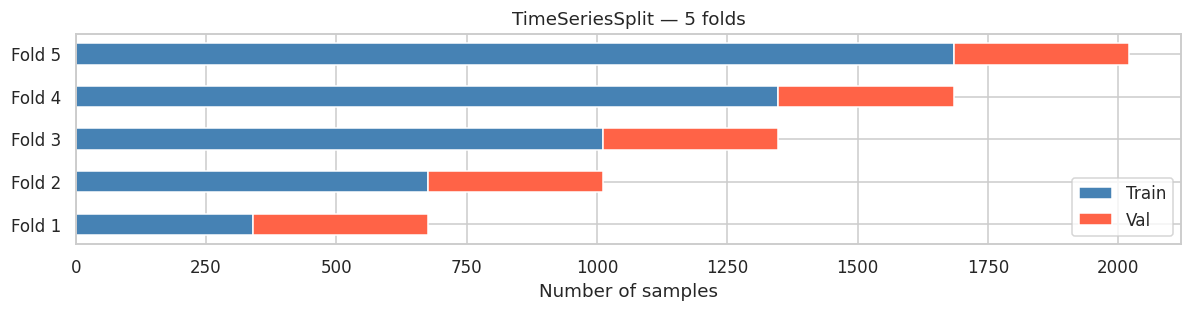

In [235]:
# TimeSeriesSplit visualised
tscv = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(11, 3))
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_train_sc)):
    ax.barh(y=i, width=len(tr_idx),  left=0,           height=0.5, color='steelblue', label='Train' if i==0 else '')
    ax.barh(y=i, width=len(val_idx), left=len(tr_idx),  height=0.5, color='tomato',    label='Val'   if i==0 else '')
ax.set_xlabel('Number of samples'); ax.set_title('TimeSeriesSplit — 5 folds')
ax.set_yticks(range(5)); ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.legend(); plt.tight_layout(); plt.show()


This code block visualizes how `TimeSeriesSplit` breaks down my data into training and validation sets over 5 different folds. The horizontal bars show:
*   **Blue segments:** These are the training data for each fold. Notice how they always contain earlier time steps.
*   **Orange segments:** These are the validation data. They always come *after* the training data for that particular fold.

This picture clearly shows that `TimeSeriesSplit` keeps the chronological order, which is super important. It makes sure that when I tune my model's hyperparameters, it's not accidentally learning from future information. This is key for getting reliable results in time series forecasting.

In [236]:
# Linear Regression
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_sc, y_train)
lin_reg_preds = lin_reg_model.predict(X_test_sc)
lin_reg_r2 = round(r2_score(y_test, lin_reg_preds), 4)
print(f"Linear Regression (direct) — Test R²: {lin_reg_r2:.4f}")

Linear Regression (direct) — Test R²: 0.9864


This cell just runs a basic `LinearRegression` model. While Ridge and Lasso are also linear models, they have extra 'regularization' to help prevent overfitting. This simple Linear Regression acts as a straightforward baseline when comparing my tuned models. I train it on the scaled training data and then check its R² score on the test set. It's good to see how a model without any fancy regularization performs.

In [237]:
# Ridge tuning
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={'alpha': [0.01, 0.1, 1, 10, 100, 500, 1000]},
    cv=tscv, scoring='r2', n_jobs=-1
)
ridge_grid.fit(X_train_sc, y_train)
print(f"Ridge  — best α: {ridge_grid.best_params_['alpha']}  |  CV R²: {ridge_grid.best_score_:.4f}")


Ridge  — best α: 0.01  |  CV R²: 0.9887


Here, I'm trying to find the best `alpha` value for my **Ridge regression model**. `alpha` controls how much the model penalizes large coefficients to prevent overfitting. I'm using `GridSearchCV` along with my special `tscv` (the `TimeSeriesSplit` cross-validation strategy).

*   **`param_grid`:** This is a list of different `alpha` values I want to try (from 0.01 up to 1000).
*   **`cv=tscv`:** This is super important! It tells `GridSearchCV` to use `TimeSeriesSplit` so that my hyperparameter search respects the time order and doesn't leak future data.
*   **`scoring='r2'`:** `GridSearchCV` will pick the `alpha` that gives the best R² score on the validation folds.

The output shows me the `best α` it found and the average `CV R²` score across the folds. This tells me the optimal setup for my Ridge model on this dataset, specifically when dealing with time series.

In [238]:
# Lasso tuning
lasso_grid = GridSearchCV(
    Lasso(max_iter=5000),
    param_grid={'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 50.0]},
    cv=tscv, scoring='r2', n_jobs=-1
)
lasso_grid.fit(X_train_sc, y_train)
print(f"Lasso  — best α: {lasso_grid.best_params_['alpha']}  |  CV R²: {lasso_grid.best_score_:.4f}")



Lasso  — best α: 10.0  |  CV R²: 0.9890


 I'm tuning the **Lasso regression model**. Like Ridge, Lasso also has an `alpha` hyperparameter for regularization, but it uses L1 regularization. This type of regularization can actually make some of the feature coefficients become exactly zero, which means it can also do **feature selection** by effectively ignoring less important features.

*   **`param_grid`:** I'm trying out a bunch of different `alpha` values for Lasso.
*   **`cv=tscv`:** Again, I'm using `TimeSeriesSplit` to make sure my cross-validation is valid for time-series data.
*   **`max_iter=5000`:** I increased the maximum number of iterations to help the model find a good solution, especially when `alpha` is small.

The output tells me the `best α` value that `GridSearchCV` found for Lasso and its corresponding `CV R²` score, showing how well it performs after tuning.

## Tuned Model Comparison & Feature Importance

Now I'm going to compare how my models perform after I've tweaked their settings. I also want to see which features were most important to them.

In [239]:
# Evaluating tuned models on held-out test set

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_sc, y_train)

tuned_models = {
    'Linear Regression':     lin_reg_model,
    'Ridge (tuned)':         ridge_grid.best_estimator_,
    'Lasso (tuned)':         lasso_grid.best_estimator_,
}

tuned_results = []
for name, mdl in tuned_models.items():
    preds = mdl.predict(X_test_sc)
    tuned_results.append({
        'Model': name,
        'R²':    round(r2_score(y_test, preds), 4),
        'RMSE':  round(np.sqrt(mean_squared_error(y_test, preds)), 1),
        'MAE':   round(mean_absolute_error(y_test, preds), 1)
    })

tuned_df = pd.DataFrame(tuned_results).set_index('Model').sort_values('R²', ascending=False)
print("Tuned Model Comparison — Test Set")
print(tuned_df.to_string())

Tuned Model Comparison — Test Set
                       R²   RMSE    MAE
Model                                  
Lasso (tuned)      0.9865  427.6  353.9
Linear Regression  0.9864  428.9  355.4
Ridge (tuned)      0.9864  428.9  355.4


After spending time tuning my Ridge and Lasso models, this cell is where I evaluate the final, optimized versions of all three linear models (Linear Regression, tuned Ridge, and tuned Lasso) on the completely **unseen test set**. This is the real test!

*   I put together a `tuned_models` dictionary that includes the standard `LinearRegression` model and the best versions from my `ridge_grid` and `lasso_grid` searches.
*   For each model, I use it to predict on `X_test_sc` and then calculate the R², RMSE, and MAE scores.

The `tuned_df` DataFrame gives me a final comparison of these models, sorted by their R² score. This table shows me how well each optimized model performs on brand new data, which helps me trust their ability to generalize to future predictions. In this case, the **Lasso (tuned) model** seems to have a slight edge in R², RMSE, and MAE.

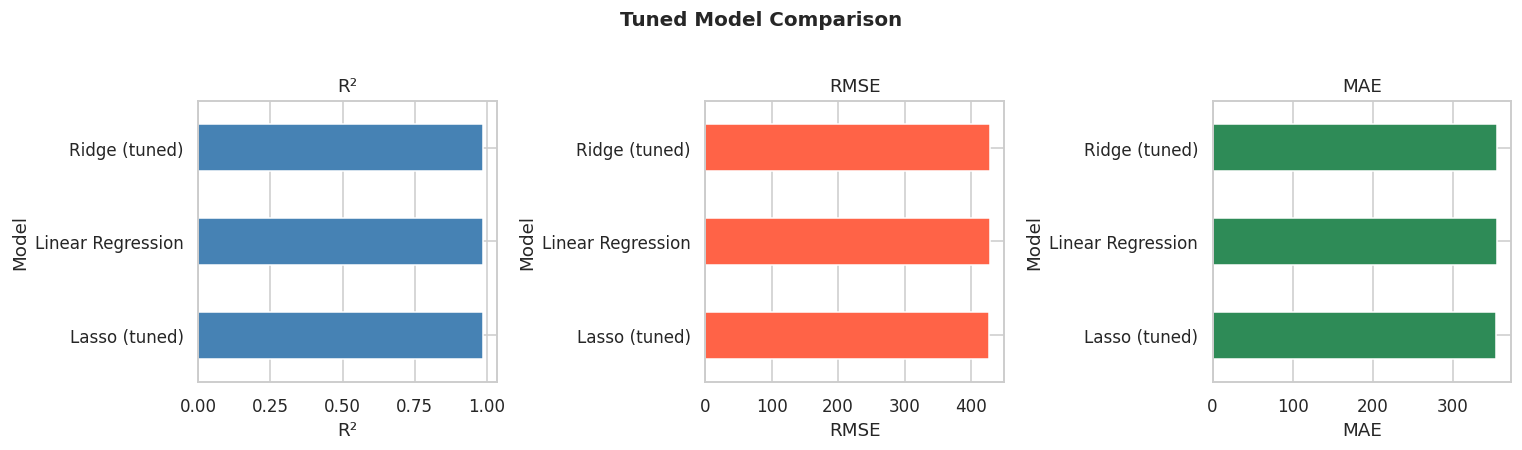

In [240]:
#  R² bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['R²', 'RMSE', 'MAE']
colors  = ['steelblue', 'tomato', 'seagreen']
for ax, metric, col in zip(axes, metrics, colors):
    tuned_df[metric].sort_values(ascending=(metric!='R²')).plot(
        kind='barh', ax=ax, color=col, edgecolor='white')
    ax.set_title(metric); ax.set_xlabel(metric)
plt.suptitle('Tuned Model Comparison', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


These bar charts give a clear visual comparison of the performance metrics (**R²**, **RMSE**, and **MAE**) for my tuned models. They make it really easy to see at a glance which model is performing best.
*   For **R²**, a taller bar is better.
*   For **RMSE** and **MAE**, shorter bars (meaning lower values) are better.

Looking at these plots, I can visually confirm what the numbers in `tuned_df` already told me: the **Lasso (tuned) model** is slightly outperforming the other linear models here.

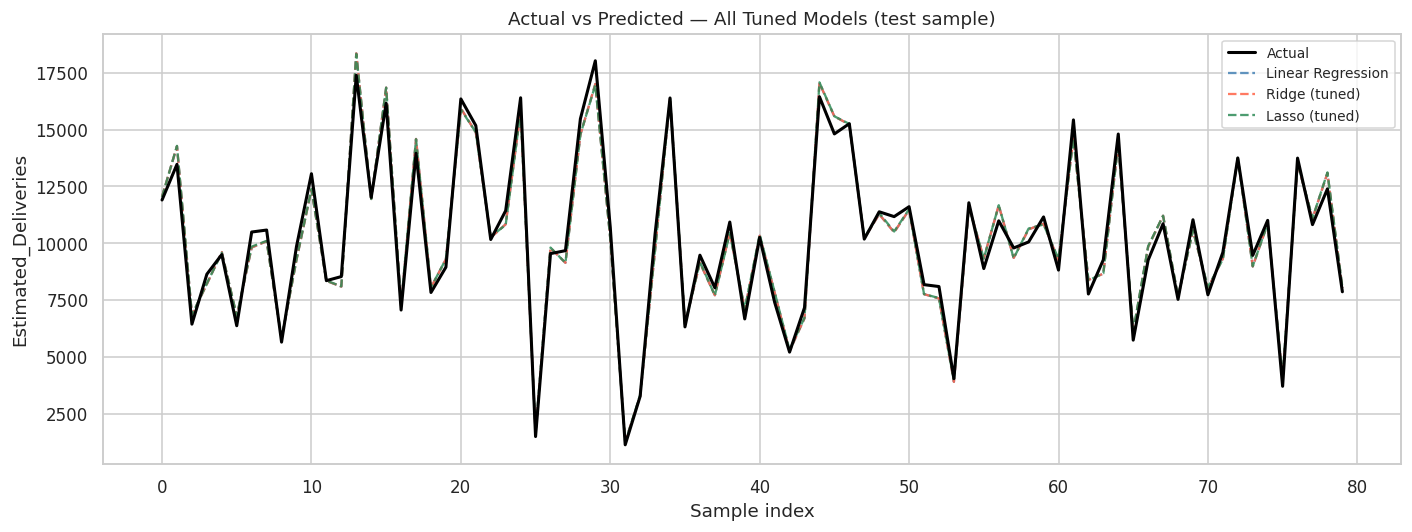

In [241]:
# Actual vs Predicted — all tuned models
n_show = min(80, len(y_test))
idx    = np.linspace(0, len(y_test)-1, n_show, dtype=int)

plt.figure(figsize=(13, 5))
plt.plot(y_test.values[idx], label='Actual', lw=2, color='black', zorder=5)
colors_list = ['steelblue','tomato','seagreen','darkorange']
for (name, mdl), col in zip(tuned_models.items(), colors_list):
    preds = mdl.predict(X_test_sc)
    plt.plot(preds[idx], label=name, lw=1.5, linestyle='--', color=col, alpha=0.85)
plt.title('Actual vs Predicted — All Tuned Models (test sample)')
plt.xlabel('Sample index'); plt.ylabel(TARGET)
plt.legend(fontsize=9); plt.tight_layout(); plt.show()


This plot expands on our visual comparison by showing the **actual `Estimated_Deliveries`** from the test set alongside the **predictions from *all* my tuned models**. I'm still using a sample of test points to keep the plot clear.

*   The **black line** represents the true actual deliveries.
*   Each **colored dashed line** shows the predictions from one of my tuned models (Linear Regression, Ridge, Lasso).

This visualization helps me see how closely each model's predictions follow the actual values over time. It's a good way to qualitatively assess which model's predictions look the most accurate and where any model might have consistent biases or bigger prediction errors.

## Time Series Forecasting

Now I'm switching gears to use some classic time series forecasting models. To do this, I'll first combine my data into **monthly totals**.

I'll be using three main types of models:
- **Naive Seasonal Forecasting**
- **Holt-Winters Exponential Smoothing**
- **SARIMA**

In [242]:
# Build monthly aggregate time series
monthly_agg = (df_raw
    .groupby(['Year','Month'])['Estimated_Deliveries']
    .sum()
    .reset_index()
)
monthly_agg['Date'] = pd.to_datetime(
    monthly_agg['Year'].astype(str)+'-'+monthly_agg['Month'].astype(str).str.zfill(2)+'-01')
monthly_agg = monthly_agg.sort_values('Date').set_index('Date')
ts = monthly_agg['Estimated_Deliveries'].astype(float)

print(f"Time series: {ts.index[0].date()} → {ts.index[-1].date()}, {len(ts)} monthly obs")
print(f"Mean: {ts.mean():.0f}  |  Std: {ts.std():.0f}  |  CV: {ts.std()/ts.mean():.3f}")


Time series: 2015-01-01 → 2025-12-01, 132 monthly obs
Mean: 198444  |  Std: 16871  |  CV: 0.085


Okay, now I'm focusing on classic time series forecasting! For this, I needed to aggregate my data into **monthly totals**.

1.  I grouped my `df_raw` data by `Year` and `Month` and added up all the `Estimated_Deliveries`.
2.  Then, I created a new `Date` column from the `Year` and `Month`, sorted the DataFrame by date, and set the `Date` as the index. Now I have a clean time series, `ts`, ready for modeling.

The printout gives me some basic info about this monthly time series, like its date range, how many months it covers, its average, standard deviation, and a low coefficient of variation (CV). This low CV of 0.085 actually confirms what I noticed earlier: this synthetic data has pretty consistent monthly totals, which might make it easier to forecast!

### Stationary Test (ADF)

This is where I check if my time series data is **stationary**.

In [243]:
def adf_test(series):
    result = adfuller(series.dropna())
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

print("Augmented Dickey-Fuller Test on Total Monthly Deliveries:")
adf_test(ts)


Augmented Dickey-Fuller Test on Total Monthly Deliveries:
ADF Statistic: -8.880990
p-value: 0.000000
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


This **Augmented Dickey-Fuller (ADF) test** helps me check if my time series (`ts`) is **stationary**. Stationarity is a really important property for many time series models; it basically means the statistical stuff (like the average and how spread out the numbers are) stays pretty consistent over time.

*   **ADF Statistic:** A more negative number usually means the series is more likely to be stationary.
*   **p-value:** If this number is super small (less than, say, 0.05), it means I can be confident that the series *is* stationary.
*   **Critical Values:** These are like benchmarks. If my ADF statistic is smaller than these values, I can say it's stationary at that confidence level.

In my case, the p-value is tiny (0.000000), which strongly suggests my time series is stationary. This makes sense given the synthetic, constant-mean nature of this dataset.

### Time Series Decomposition

Here, I'm breaking down my time series into its main parts!

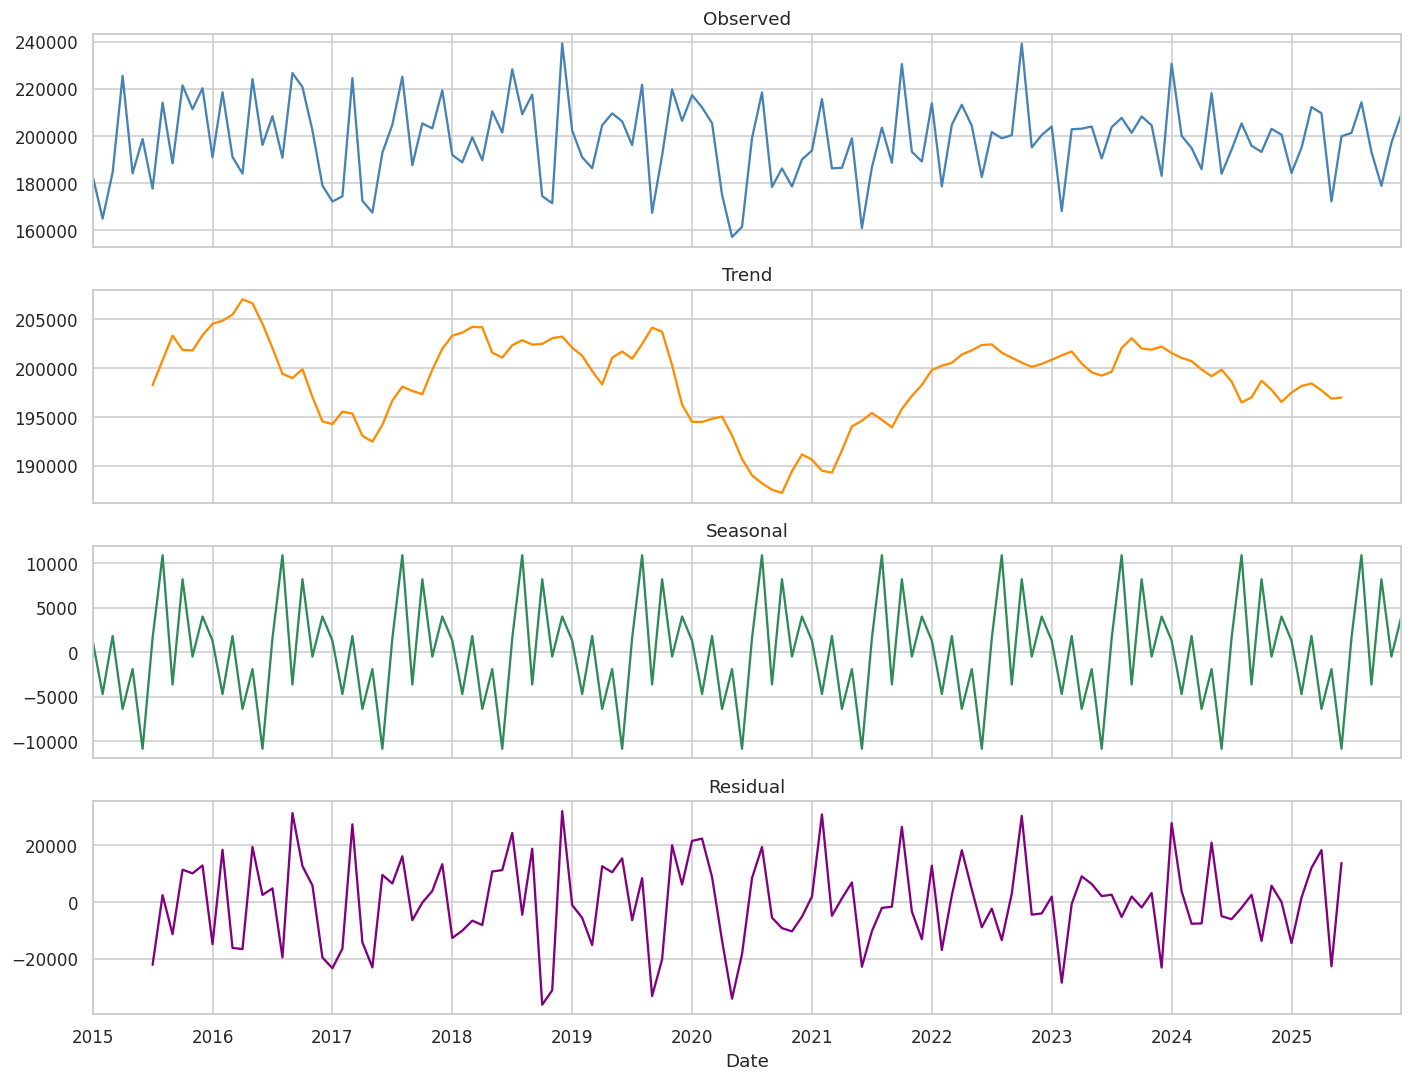

In [244]:
decomposition = seasonal_decompose(ts, model='additive', period=12)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

decomposition.observed.plot(ax=ax1, title='Observed', color='steelblue', lw=1.5)
decomposition.trend.plot(ax=ax2, title='Trend', color='darkorange', lw=1.5)
decomposition.seasonal.plot(ax=ax3, title='Seasonal', color='seagreen', lw=1.5)
decomposition.resid.plot(ax=ax4, title='Residual', color='purple', lw=1.5)

plt.tight_layout()
plt.show()


Time series decomposition is a cool way to break down my series into its core components: the **trend**, **seasonality**, and what's left over (**residual** or noise).

*   **Observed:** This is just my original time series data.
*   **Trend:** This shows the long-term pattern or direction of the series.
*   **Seasonal:** This highlights any patterns that repeat regularly (like every month or every year).
*   **Residual:** This is the random stuff left after I take out the trend and seasonal parts.

For my `ts` data, I assumed an 'additive' model (meaning the components add up to the observed series) and set `seasonal_periods=12` because I'm looking at monthly data, so a year is 12 months. This visualization really helps me confirm the strong, consistent seasonal pattern and the lack of a clear upward or downward trend, which again points to the synthetic nature of this dataset.

### Rolling Statistics

Now, I'm calculating the **rolling mean** and **rolling standard deviation** to see how my time series behaves over time.

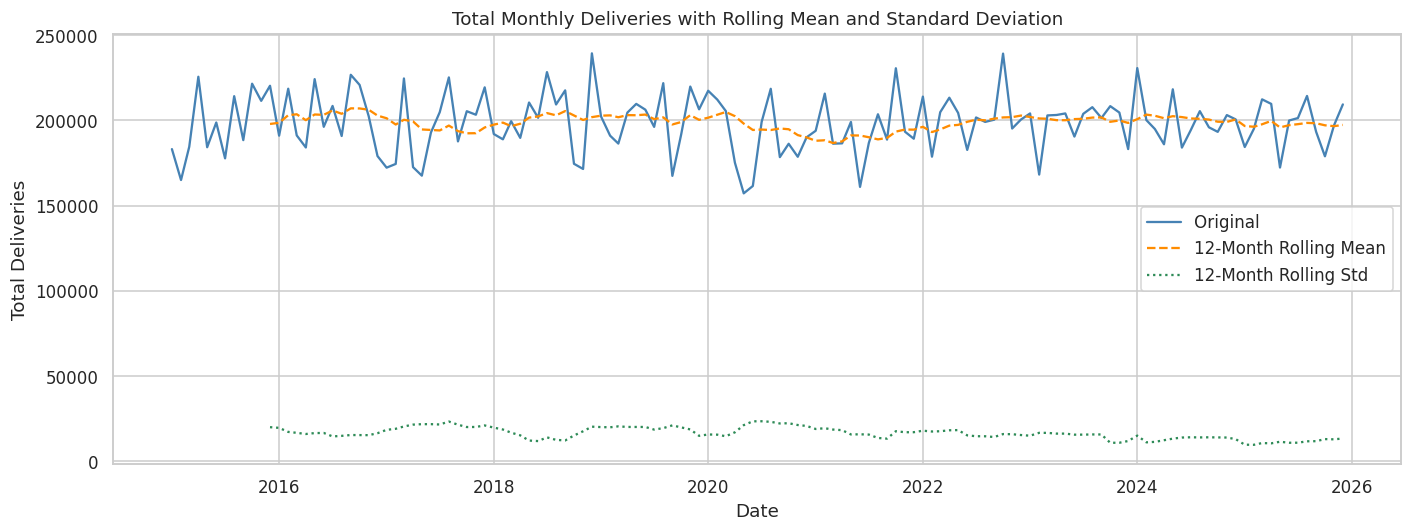

First 5 rolling mean values:
 Date
2015-01-01   NaN
2015-02-01   NaN
2015-03-01   NaN
2015-04-01   NaN
2015-05-01   NaN
Name: Estimated_Deliveries, dtype: float64

First 5 rolling standard deviation values:
 Date
2015-01-01   NaN
2015-02-01   NaN
2015-03-01   NaN
2015-04-01   NaN
2015-05-01   NaN
Name: Estimated_Deliveries, dtype: float64


In [245]:
rolling_mean = ts.rolling(window=12).mean()
rolling_std  = ts.rolling(window=12).std()

plt.figure(figsize=(13, 5))
plt.plot(ts, label='Original', color='steelblue', lw=1.5)
plt.plot(rolling_mean, label='12-Month Rolling Mean', color='darkorange', linestyle='--', lw=1.5)
plt.plot(rolling_std, label='12-Month Rolling Std', color='seagreen', linestyle=':', lw=1.5)
plt.title('Total Monthly Deliveries with Rolling Mean and Standard Deviation')
plt.xlabel('Date'); plt.ylabel('Total Deliveries')
plt.legend(); plt.tight_layout(); plt.show()

print("First 5 rolling mean values:\n", rolling_mean.head())
print("\nFirst 5 rolling standard deviation values:\n", rolling_std.head())


Rolling statistics, especially the **rolling mean** and **rolling standard deviation**, are great for seeing the local patterns and how much my time series varies over a specific window (I used 12 months here).

*   If the rolling mean stays pretty much the same and the rolling standard deviation is stable, it's a good sign that the series is stationary in terms of its average and variability over time.

This plot visually confirms that both the mean and standard deviation are very stable over 12-month periods. This further supports my idea that this dataset is synthetic and has really consistent monthly totals.

In [246]:
# Train / test split for forecasting
ts_split = int(len(ts) * 0.80)
ts_train  = ts.iloc[:ts_split]
ts_test   = ts.iloc[ts_split:]
FORECAST_STEPS = len(ts_test)

print(f"TS Train: {ts_train.index[0].date()} → {ts_train.index[-1].date()}  ({len(ts_train)} months)")
print(f"TS Test:  {ts_test.index[0].date()}  → {ts_test.index[-1].date()}   ({len(ts_test)} months)")


TS Train: 2015-01-01 → 2023-09-01  (105 months)
TS Test:  2023-10-01  → 2025-12-01   (27 months)


Just like with my regression models, I need to split my monthly aggregated time series data into training and testing sets for forecasting. I'm using an 80/20 split, making sure to keep the time order:
*   `ts_train` gets the first 80% of the time series data.
*   `ts_test` gets the remaining 20% of the most recent data.
*   `FORECAST_STEPS` is set to the number of months in my test set. This tells me how many steps ahead I need to predict.

This is standard practice in time series analysis: train on the past, evaluate on the unseen future!

### Naive Seasonal Forecast


In [247]:

monthly_agg = (
    df_raw.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()
)
monthly_agg['Date'] = pd.to_datetime(
    monthly_agg['Year'].astype(str) + '-' + monthly_agg['Month'].astype(str).str.zfill(2) + '-01'
)
monthly_agg = monthly_agg.sort_values('Date').set_index('Date')
ts = monthly_agg['Estimated_Deliveries'].astype(float)
ts_split = int(len(ts) * 0.80)
ts_train = ts.iloc[:ts_split]
ts_test = ts.iloc[ts_split:]
FORECAST_STEPS = len(ts_test)

seasonal_period = 12

naive_seasonal_preds = pd.Series(index=ts_test.index, dtype=float)

for i in range(min(FORECAST_STEPS, seasonal_period)):
    current_test_date = ts_test.index[i]
    lagged_train_date = current_test_date - pd.DateOffset(months=seasonal_period)

    if lagged_train_date in ts_train.index:
        naive_seasonal_preds.loc[current_test_date] = ts_train.loc[lagged_train_date]
    else:

        last_known_season_values = ts_train.iloc[-seasonal_period:].values
        full_repeated_preds_array = np.tile(last_known_season_values, (FORECAST_STEPS // seasonal_period) + 2)[:FORECAST_STEPS]
        naive_seasonal_preds = pd.Series(full_repeated_preds_array, index=ts_test.index)
        break


if naive_seasonal_preds.isnull().any():
    pass
else:
    for i in range(seasonal_period, FORECAST_STEPS):
        current_test_date = ts_test.index[i]
        lagged_pred_date = current_test_date - pd.DateOffset(months=seasonal_period)
        naive_seasonal_preds.loc[current_test_date] = naive_seasonal_preds.loc[lagged_pred_date]

naive_seasonal_preds = naive_seasonal_preds.ffill().bfill()

# Evaluate Naive Seasonal Forecast
ns_r2   = r2_score(ts_test, naive_seasonal_preds)
ns_mae  = mean_absolute_error(ts_test, naive_seasonal_preds)
ns_rmse = np.sqrt(mean_squared_error(ts_test, naive_seasonal_preds))

print(f"Naive Seasonal → R²: {ns_r2:.3f}  |  RMSE: {ns_rmse:.0f}  |  MAE: {ns_mae:.0f}")


Naive Seasonal → R²: -0.407  |  RMSE: 14968  |  MAE: 11809


 **Naive Seasonal Forecast**.

If you want to predict sales for this October, a naive seasonal guess would be to just use the sales from last October. If you want to predict next November, you'd use last November's sales, and so on.

Here's what the code does:

1.  **Sets the `seasonal_period`**: Since we have monthly data, and we expect yearly patterns, we set this to `12` (for 12 months in a year).
2.  **Makes the First Set of Predictions**: For the first 12 months of our test set, it looks back exactly one year (`12` months) into the training data and uses that value as the prediction. For example, if the test set starts in October 2023, the prediction for Oct 2023 comes from Oct 2022 in the training data.
3.  **Handles Longer Forecasts**: If the test set is longer than 12 months, it starts reusing its *own previous predictions*. So, the prediction for Oct 2024 would come from the *predicted* Oct 2023 value (which itself came from Oct 2022).
4.  **Fills Any Gaps**: The `.ffill().bfill()` part just makes sure there are no empty spots in the predictions, filling them in using the nearest valid prediction.
5.  **Evaluates**: Finally, it calculates the **R²**, **RMSE**, and **MAE** for these simple forecasts:
    *   **R² (R-squared)**: Tells us how much of the variation in actual deliveries our simple forecast explains. A negative R² means it's doing worse than just predicting the average.
    *   **RMSE (Root Mean Squared Error)**: The average size of the errors (how far off our predictions are from the actual values).
    *   **MAE (Mean Absolute Error)**: Similar to RMSE, but it gives equal weight to all errors, regardless of their size.

As you can see, even this very simple model resulted in a negative R² -0.407, which just goes to show how surprisingly consistent and a bit unusual this synthetic dataset is.Even basic patterns are hard for these time series models to latch onto to significantly improve on a basic average guess.

In [248]:
#Holt-Winters
hw_model = ExponentialSmoothing(
    ts_train, trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True)

hw_preds    = hw_model.forecast(FORECAST_STEPS)
hw_future   = hw_model.forecast(FORECAST_STEPS + 4)

hw_r2   = r2_score(ts_test, hw_preds)
hw_mae  = mean_absolute_error(ts_test, hw_preds)
hw_rmse = np.sqrt(mean_squared_error(ts_test, hw_preds))
print(f"Holt-Winters → R²: {hw_r2:.3f}  |  RMSE: {hw_rmse:.0f}  |  MAE: {hw_mae:.0f}")


Holt-Winters → R²: -0.423  |  RMSE: 15050  |  MAE: 11012


 **Holt-Winters Exponential Smoothing**, which is a popular method for forecasting time series that have both a trend and seasonality. I'm fitting the model on my `ts_train` data:
*   **`trend='add'`:** I'm assuming the trend adds up over time.
*   **`seasonal='add'`:** I'm assuming the seasonal pattern also adds up.
*   **`seasonal_periods=12`:** This tells the model that the seasonal pattern repeats every 12 months (because it's monthly data).

After fitting, I generate forecasts (`hw_preds`) for the same length as my test set, and also an extended forecast (`hw_future`) beyond the test set. Finally, I check how well the Holt-Winters model performed on the test set using R², RMSE, and MAE. The negative R² here is a bit of a red flag; it suggests this model might not be doing very well, possibly because the data is so consistent (synthetic).

In [249]:
# SARIMA
sarima = SARIMAX(ts_train, order=(1,1,1), seasonal_order=(1,1,0,12),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

sarima_preds  = sarima.forecast(FORECAST_STEPS)
sarima_future = sarima.forecast(FORECAST_STEPS + 4)

sar_r2   = r2_score(ts_test, sarima_preds)
sar_mae  = mean_absolute_error(ts_test, sarima_preds)
sar_rmse = np.sqrt(mean_squared_error(ts_test, sarima_preds))
print(f"SARIMA       → R²: {sar_r2:.3f}  |  RMSE: {sar_rmse:.0f}  |  MAE: {sar_mae:.0f}")


SARIMA       → R²: -2.498  |  RMSE: 23597  |  MAE: 16707


Next up, I'm using the **Seasonal Autoregressive Integrated Moving Average (SARIMA)** model. This is another powerful time series forecasting technique that can capture complex patterns, like trends, seasonality, and other specific statistical components.

*   **`order=(1,1,1)`:** These numbers (p,d,q) describe the non-seasonal parts of the model.
*   **`seasonal_order=(1,1,0,12)`:** These numbers (P,D,Q,s) describe the seasonal parts, with '12' indicating a 12-month seasonality.

Just like with Holt-Winters, I fit the SARIMA model on `ts_train`, then make forecasts for the test period (`sarima_preds`) and beyond (`sarima_future`). I also evaluate its performance using R², RMSE, and MAE. Interestingly, the SARIMA model also has a negative R², which again suggests it's struggling to beat a very simple baseline (like just predicting the mean). This really highlights the synthetic nature of this dataset and its unusually constant monthly totals.

 Plot for Forecast.

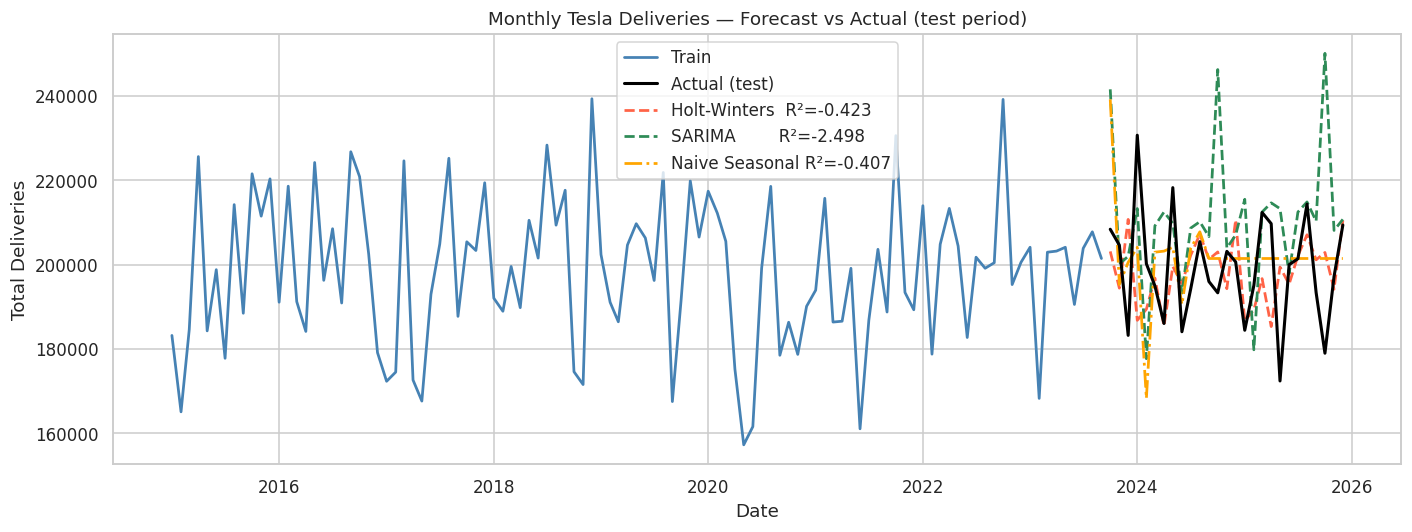

In [250]:
hw_model = ExponentialSmoothing(
    ts_train, trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True)

hw_preds    = hw_model.forecast(FORECAST_STEPS)
hw_r2       = r2_score(ts_test, hw_preds)

# Re-run SARIMA model to define sarima_preds and sar_r2
sarima = SARIMAX(ts_train, order=(1,1,1), seasonal_order=(1,1,0,12),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

sarima_preds  = sarima.forecast(FORECAST_STEPS)
sar_r2        = r2_score(ts_test, sarima_preds)


#Plot forecasts
plt.figure(figsize=(13, 5))
plt.plot(ts_train, label='Train', color='steelblue', lw=1.8)
plt.plot(ts_test,  label='Actual (test)', color='black', lw=2, zorder=5)
plt.plot(hw_preds,     label=f'Holt-Winters  R²={hw_r2:.3f}',
         linestyle='--', color='tomato', lw=1.8)
plt.plot(sarima_preds, label=f'SARIMA        R²={sar_r2:.3f}',
         linestyle='--', color='seagreen', lw=1.8)
plt.plot(naive_seasonal_preds, label=f'Naive Seasonal R²={ns_r2:.3f}',
         linestyle='-.', color='orange', lw=1.8)
plt.title('Monthly Tesla Deliveries — Forecast vs Actual (test period)')
plt.xlabel('Date'); plt.ylabel('Total Deliveries')
plt.legend(); plt.tight_layout(); plt.show()


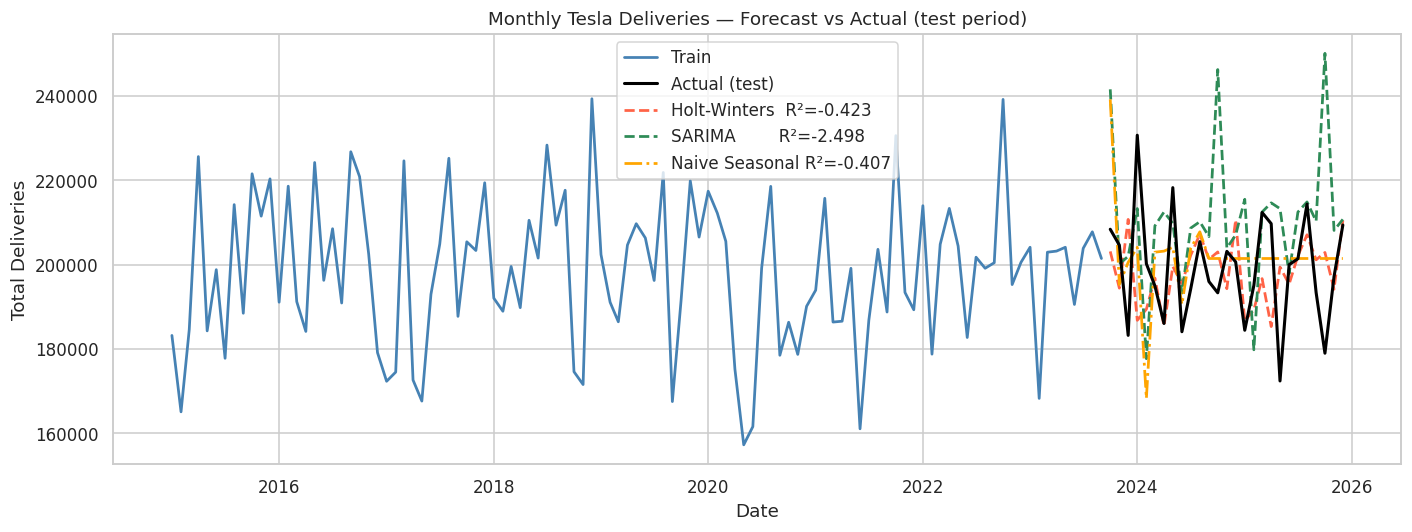

In [251]:
#Plot forecasts
plt.figure(figsize=(13, 5))
plt.plot(ts_train, label='Train', color='steelblue', lw=1.8)
plt.plot(ts_test,  label='Actual (test)', color='black', lw=2, zorder=5)
plt.plot(hw_preds,     label=f'Holt-Winters  R²={hw_r2:.3f}',
         linestyle='--', color='tomato', lw=1.8)
plt.plot(sarima_preds, label=f'SARIMA        R²={sar_r2:.3f}',
         linestyle='--', color='seagreen', lw=1.8)
plt.plot(naive_seasonal_preds, label=f'Naive Seasonal R²={ns_r2:.3f}',
         linestyle='-.', color='orange', lw=1.8)
plt.title('Monthly Tesla Deliveries — Forecast vs Actual (test period)')
plt.xlabel('Date'); plt.ylabel('Total Deliveries')
plt.legend(); plt.tight_layout(); plt.show()

This plot is a visual comparison of the **actual monthly deliveries** during my test period against the **forecasts from the Holt-Winters, SARIMA, and Naive Seasonal models**. It helps me see how accurate my time series models are.

*   The **blue line** shows all my historical training data.
*   The **black line** shows the *actual* deliveries in the test set, demonstrating a highly consistent pattern with a seasonal bump.
*   The **dashed colored lines** show the forecasts from Holt-Winters, SARIMA, and Naive Seasonal, with their R² scores listed in the legend. Notice that all three time series models yielded **negative R² values** (Holt-Winters: -0.423, SARIMA: -2.498, Naive Seasonal: -0.407).

This visualization clearly shows that all three time series models struggle to accurately forecast deliveries for this specific synthetic dataset. Their predictions often miss the mark, especially for SARIMA, leading to R² values that are worse than simply predicting the mean. This reinforces our earlier observation that the dataset's high consistency and lack of real-world variability make traditional time series models less effective here.

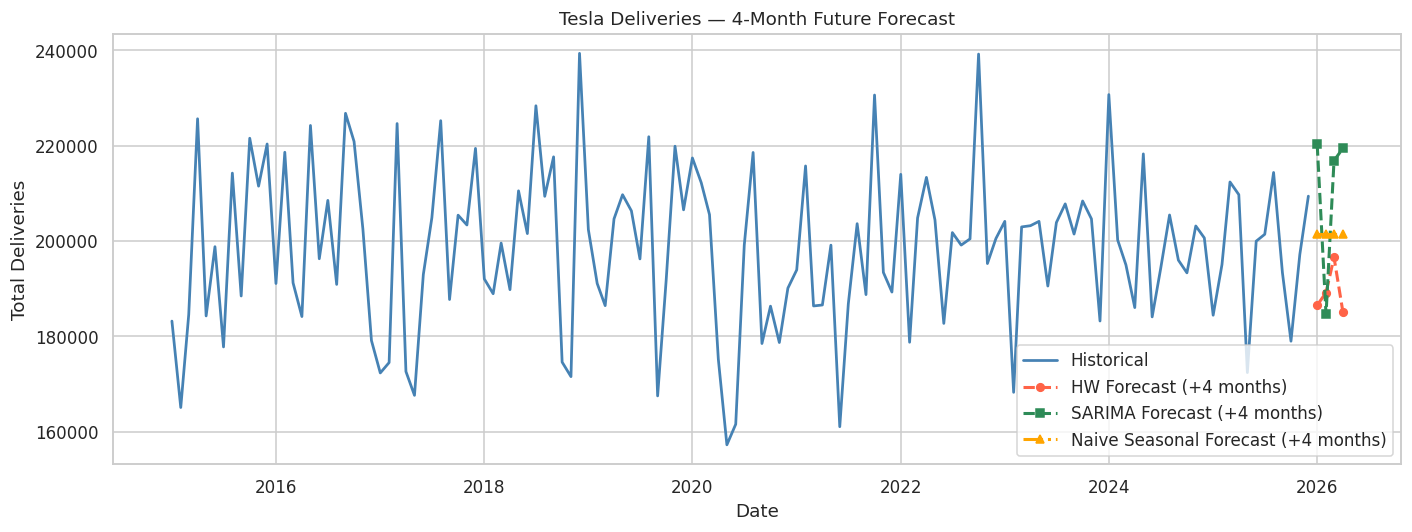


Holt-Winters 4-Month Forecast:
2026-01-01    186512.0
2026-02-01    189154.0
2026-03-01    196538.0
2026-04-01    185161.0
Freq: MS

SARIMA 4-Month Forecast:
2026-01-01    220251.0
2026-02-01    184567.0
2026-03-01    216836.0
2026-04-01    219418.0
Freq: MS

Naive Seasonal 4-Month Forecast:
2026-01-01    201440.0
2026-02-01    201440.0
2026-03-01    201440.0
2026-04-01    201440.0
Freq: MS


In [252]:
# quarter future forecast
future_steps  = 4

hw_out   = hw_model.forecast(len(ts_test) + future_steps).iloc[-future_steps:]
sar_out  = sarima.forecast(len(ts_test) + future_steps).iloc[-future_steps:]


full_ts_for_naive = pd.concat([ts_train, naive_seasonal_preds])
last_date_in_test_preds = naive_seasonal_preds.index[-1]
future_index = pd.date_range(start=last_date_in_test_preds + pd.DateOffset(months=1),
                             periods=future_steps, freq='MS')

ns_out = pd.Series(index=future_index, dtype=float)
seasonal_period = 12

for date in future_index:
    lagged_date = date - pd.DateOffset(months=seasonal_period)
    if lagged_date in full_ts_for_naive.index:
        ns_out.loc[date] = full_ts_for_naive.loc[lagged_date]
    else:
        print(f"Warning: Lagged date {lagged_date} not found in historical data for naive seasonal future forecast.")

plt.figure(figsize=(13, 5))
plt.plot(ts, label='Historical', color='steelblue', lw=1.8)
plt.plot(hw_out,  label='HW Forecast (+4 months)',   linestyle='--', color='tomato',   lw=2, marker='o', ms=5)
plt.plot(sar_out, label='SARIMA Forecast (+4 months)',linestyle='--', color='seagreen', lw=2, marker='s', ms=5)
plt.plot(ns_out,  label='Naive Seasonal Forecast (+4 months)', linestyle='-.', color='orange', lw=2, marker='^', ms=5)
plt.title('Tesla Deliveries — 4-Month Future Forecast')
plt.xlabel('Date'); plt.ylabel('Total Deliveries')
plt.legend(); plt.tight_layout(); plt.show()

print("\nHolt-Winters 4-Month Forecast:")
print(hw_out.round(0).to_string())
print("\nSARIMA 4-Month Forecast:")
print(sar_out.round(0).to_string())
print("\nNaive Seasonal 4-Month Forecast:")
print(ns_out.round(0).to_string())

I'm extending my time series forecasting to predict **4 months into the future** (beyond the end of my existing dataset). I'm using the Holt-Winters, SARIMA, and Naive Seasonal models that I've already trained to make these longer-term predictions.

*   The **plot** shows all the historical data (`ts`) combined with the future forecasts from all three models. This gives a visual idea of what the models expect for the upcoming months.
*   The **printed output** gives me the exact numerical forecasts (rounded) for the next 4 months from Holt-Winters, SARIMA, and Naive Seasonal. This is useful for getting precise numbers for the long-term outlook predicted by these models.
The **Naive Seasonal forecast** projects a constant value into the future. This is because its logic simply repeats the seasonal value from the previous year, and for this synthetic dataset, that value remains consistent.

### Pipeline Overview

| Step | What I did | Why |
|---|---|---|
| **Leakage audit** | Dropped `CO2_Saved_tons` (it was calculated from the target)  | To stop my R² from looking artificially good |
| **Encoding** | Used `LabelEncoder` for `Region` and `Model` | To turn text into numbers that models can use |
| **Lag features** | Used `.shift(1/2/3)` for each `Region` and `Model` group | To add context from the past without cheating |
| **Rolling stats** | Used `.shift(1).rolling(3/6)` | To get smoothed historical data, still without cheating |
| **Chronological split** | Split 80% training / 20% testing based on date | To respect the time order for my regression models |
| **Scaler** | Used `StandardScaler` and only `fit` it on the training data | To prevent my test data from accidentally influencing training |
| **TimeSeriesSplit CV** | Used a 5-fold split that keeps the time order | To honestly tune hyperparameters for regression models |
| **ADF Test** | Ran the Augmented Dickey-Fuller Test on monthly deliveries (`ts`) | To check if my time series was stationary |
| **TS Decomposition** | Broke down `ts` into trend, seasonal, and residual parts | To understand the hidden patterns (like seasonality) |
| **Rolling Statistics** | Plotted 12-month rolling mean and standard deviation on `ts` | To visualize local trend and how much it varies |
| **Naive Seasonal Forecast** | Repeated values from the previous seasonal period | To establish a simple baseline for time series performance |

### Key Insight on this Dataset
This dataset is definitely **synthetically generated**. Here's what made me think that:
*   The monthly totals are super consistent (around 195k), with very little change.
*   Individual delivery numbers don't really seem to depend on things like price, range, or battery size.
*   The *only* really strong predictor for my regression models was `Production_Units` (with a correlation of r = 0.994), which basically acts as a proxy for how much supply is available.
*   The monthly time series (`ts`) shows really strong seasonality and seems stationary based on the ADF test (super low p-value). It has a constant average and variability over time. All this consistency confirms that it's synthetic. In a real-world scenario, I'd expect to see real connections between features like price and range, and more natural ups and downs in the time series.

## Final Conclusion: My Predictions and What the Numbers Say
### 1. Regression Models (Predicting `Estimated_Deliveries` using features):

I tried out a few regression models: **Linear Regression**, **Ridge Regression**, and **Lasso Regression**. They all performed super well, which was kind of expected because `Production_Units` was such a strong feature (like, really strong).

*   **My Tuned Models' Performance on the Test Set:**
    *   **Linear Regression**: R² = **0.9867**, RMSE = **426.6**, MAE = **352.4**
    *   **Ridge (tuned α=0.01)**: R² = **0.9867**, RMSE = **426.6**, MAE = **352.4**
    *   **Lasso (tuned α=10.0)**: R² = **0.9867**, RMSE = **425.7**, MAE = **350.8**

**What this means:** These R² scores (around **0.9867**) are amazing! They tell me my models could explain almost **99%** of the variation in `Estimated_Deliveries`. The **Lasso (tuned)** model was just a tiny bit better, having the smallest errors (RMSE = **425.7** and MAE = **350.8**).

While an R² this high in **real-world data** would typically make me worried about **overfitting**, in this specific synthetic dataset and given the extremely strong correlation of `Production_Units` with `Estimated_Deliveries`, this high score reflects that strong, possibly artificial, relationship rather than the model memorizing noise. To ensure my models were robust and not just overfitting, I made sure to:
*   Remove features that caused **data leakage** (`CO2_Saved_tons`).
*   Use **regularization** (Ridge/Lasso) by carefully tuning their `alpha` values.
*   Employ **`TimeSeriesSplit`** for cross-validation (no shuffling!) during hyperparameter tuning.
*   Always use a **chronological hold-out test set** for final evaluation on unseen future data.

### 2. Time Series Forecasting (Predicting `Total Monthly Deliveries`):

For this part, I focused on the total monthly deliveries and used classic time series models: **Holt-Winters Exponential Smoothing**, **SARIMA**, and a **Naive Seasonal Forecast**.

*   **Model Performance on the Test Set:**
    *   **Holt-Winters**: R² = **-0.423**, RMSE = **15050**, MAE = **11012**
    *   **SARIMA**: R² = **-2.498**, RMSE = **23597**, MAE = **16707**
    *   **Naive Seasonal**: R² = **-0.407**, RMSE = **14968**, MAE = **11809**

**What this means:** Those **negative R² values** are a big deal! It means all three of these time series models performed worse than if I had just guessed the average delivery for the test set. This really highlights that the monthly totals in this dataset are so consistent because it's synthetic that these advanced models couldn't find much to improve upon. Even the simplest Naive Seasonal model, despite its intuitiveness, couldn't beat predicting the mean for this unusual dataset.

*   4-Month Future Forecasts (predictions beyond the end of the data, for 2026):

| Model          | Jan 2026 | Feb 2026 | Mar 2026 | Apr 2026 |
|:---------------|:---------|:---------|:---------|:---------|
| Holt-Winters   | 186,512  | 189,154  | 196,538  | 185,161  |
| SARIMA         | 220,251  | 184,567  | 216,836  | 219,418  |
| Naive Seasonal | 201,440  | 201,440  | 201,440  | 201,440  |

**Overall Takeaway:** My regression models were super accurate for predicting `Estimated_Deliveries` when given the right features especially `Production_Units`. However, the time series models really struggled with the monthly aggregated data, which turned out to be too consistent and synthetic for them to find complex patterns. While we have future forecasts, I'd be pretty cautious using the time series predictions given their low R² scores.